# 📊 State Transition Log EDA — FSM Transition Analysis

This notebook performs exploratory data analysis (EDA) on the **state transition log** from a CodeCritic execution session. It reconstructs the FSM state transitions, visualizes system progression, and highlights key execution patterns such as delays, bottlenecks, and step behaviors.

## 🔍 Contents

* **Execution Timeline**: Chronological order of FSM state transitions with a focus on program, controller, system, and state transitions.
* **Transition Reason Distribution**: Visualizes the frequency of different transition reasons across the system.
* **Step Distribution**:

  * Maximum steps per FSM type (Program, Controller, System, State)
  * Number of steps per run, showing the progression of execution across each FSM type.
* **Latency Analysis**:

  * Total latency analysis by FSM state type.
  * Transition duration for different FSM layers to identify performance bottlenecks.
* **FSM Layer Grouping**:

  * Grouped Gantt charts to visualize how different FSM layers (Program → Controller → System → State) progress over time.
  * Color-coded timelines by `run_id` to differentiate concurrent runs.
* **Gantt Chart Visuals**: Visualizes the transitions as horizontal bars grouped by FSM type, showing the execution duration across the timeline.

## 🎯 Goal

The goal of this notebook is to **analyze the flow of state transitions** in the system, understand **performance bottlenecks** across different FSM layers, identify potential **issues in the state transition process**, and surface **optimization opportunities**. By doing so, we aim to improve system performance, enhance reliability, and identify key areas for design improvements within CodeCritic's FSM execution.

### 🛠️ Project Root Setup + Database Reset and Seeding

This cell resets the entire database schema and seeds it with initial data. It is typically used in local development or test environments before running sessions.

#### 🧠 What this code does:

1. **Sets the working directory** to the project root (`C:\Repos\codecritic`) so all relative imports and paths resolve correctly.
2. **Imports all seeders** from `app.db.seeders` to populate the database with provider and configuration records.
3. **Drops and recreates** all tables using SQLAlchemy’s `Base.metadata.drop_all()` and `create_all()` for a clean start.
4. **Runs all seeders** in a single transaction using `Session(bind=engine)` to insert:
   - Prompts and prompt providers
   - Tools, scores, and agent engines
   - Agents, states, systems, controllers, programs, and sessions
5. **Loads environment variables** from `env/.env` relative to the project root.

#### 🔍 Why it matters:

- Ensures the system starts from a **clean and reproducible state**
- Guarantees that all required provider records are seeded before executing sessions
- Makes local development or testing **deterministic**
- Prepares the environment for any downstream scripts, agents, or workflows

Use this cell at the start of notebooks that need access to a freshly initialized and fully seeded CodeCritic environment.

In [1]:
from pathlib import Path
import os, sys
from dotenv import load_dotenv

# Set working directory explicitly to project root
PROJECT_ROOT = Path(r"C:\Repos\codecritic").resolve()

os.chdir(PROJECT_ROOT)  # Change current directory
sys.path.insert(0, str(PROJECT_ROOT))  # Ensure imports resolve correctly

print("Working directory is now:", Path.cwd())

from app.db.connection import DB_PATH, close_connection
from sqlalchemy import create_engine
from app.db.seeders.seed_score_providers import seed_score_providers
from app.db.seeders.seed_tool_providers import seed_tool_providers
from app.db.seeders.seed_prompt_providers import seed_prompt_providers
from app.db.seeders.seed_prompts import seed_prompts
from app.db.seeders.seed_context_providers import seed_context_providers
from app.db.seeders.seed_agent_engine_providers import seed_agent_engine_providers
from app.db.seeders.seed_agent_providers import seed_agent_providers
from app.db.seeders.seed_state_providers import seed_state_providers
from app.db.seeders.seed_system_providers import seed_system_providers
from app.db.seeders.seed_controller_providers import seed_controller_providers
from app.db.seeders.seed_program_provider import seed_program_providers
from app.db.seeders.seed_session_configs import seed_session_configs
from app.db.base import Base
from sqlalchemy.orm import Session

# 🧹 Reset DB
close_connection()
engine = create_engine(f"sqlite:///{DB_PATH}")
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)

# 🌱 Seed database records
with Session(bind=engine) as session:
    seed_prompts(session)
    seed_prompt_providers(session)
    seed_tool_providers(session)
    seed_score_providers(session)
    seed_context_providers(session)
    seed_agent_engine_providers(session)
    seed_agent_providers(session)
    seed_state_providers(session)
    seed_system_providers(session)
    seed_controller_providers(session)
    seed_program_providers(session)
    seed_session_configs(session)

# Load from env/.env relative to project root
dotenv_path = Path("env/.env").resolve()
if dotenv_path.exists():
    load_dotenv(dotenv_path)
    print("✅ Loaded environment variables from env/.env")
else:
    raise FileNotFoundError(f"❌ Missing .env file at: {dotenv_path}")


Working directory is now: C:\Repos\codecritic
Seeded AgentPrompt 'generate' with ID: 1 and GUID: 3807b8d3-c743-4ced-aebc-bfa1b0b633b6
Seeded AgentPrompt 'linting_generator_agent' with ID: 2 and GUID: 690a5512-1c64-41b1-bd4d-77688e26855e
Seeded SystemPrompt 'format' with ID: 1 and GUID: 3214b9a2-05c1-4e6e-9122-e9a46839a638
Seeded SystemPrompt 'linting_system' with ID: 2 and GUID: 6f69906c-f8e7-40e4-8372-f5294e9d12ef
Seeded prompt provider configurations successfully.
Seeded tool configurations successfully.
Seeded score providers successfully.
Seeded context provider configurations successfully.
Seeded agent engine configurations successfully.
Seeded agent provider configurations successfully.
✅ Seeded state provider configurations successfully.
✅ Seeded system provider configurations successfully.
✅ Seeded controller providers
✅ Seeded program providers
✅ Seeded session configs
✅ Loaded environment variables from env/.env


### 🧪 Run Program Using SessionConfig

This cell loads and executes a **program** using configuration data from the database, simulating a specific session's execution environment.

#### 🧠 What this code does:

* **Fetches the session configuration** from the database (with `session_id = 1`), ensuring the configuration is available.
* Prepares a **test file** (`session_linked_execution.py`) with a basic function to run.
* Constructs input data for the program, including the file path, session ID, and system context (`LINTING`).
* **Runs the program** using a factory method (`ProgramProviderFactory`), passing the input data along with session-specific configuration.
* Prints the **final result** from the program, showing the output of the execution.

#### 🔍 What you're observing:

* This step demonstrates how the system initializes the **program provider** and runs it in the context of a **specific session**.
* It’s useful for **debugging execution flows** and **validating program behavior** based on dynamic session configurations.
* **Outputs** include any results generated by the program, including runtime metadata and system responses.

This approach is fundamental for simulating **real-time program execution** tied to specific session states.


In [2]:
from app.db.models import SessionConfig
from app.enums.logging_enums import PROVIDER_TYPE
from app.enums.system_enums import SYSTEM
from app.factories.program_provider_factory import ProgramProviderFactory
from sqlalchemy.orm import Session
from pathlib import Path
import json

with Session(bind=engine) as db:
    session_row = db.query(SessionConfig).filter_by(id=1).first()
    assert session_row, "❌ No session config found"

file = Path("tests/session_linked_execution.py")
file.write_text("def ping( user ):\n return f\"pong {user}\"")

input_data = {
    "file_path":  str(file),
    "session_id": session_row.id,
    "system":     SYSTEM.LINTING.value
}

program = ProgramProviderFactory.create(
    id=session_row.program_provider_id,
    called_by_type=PROVIDER_TYPE.SESSION,
    called_by_id=session_row.id
)
result = program.run(input_data, session_id=session_row.id)

print("✅ Final Program Result (via SessionConfig):")
print(json.dumps(result.model_dump(), indent=2))


✅ Final Program Result (via SessionConfig):
{
  "state": "end",
  "previous_state": "preprocessing_controller",
  "state_type": "end",
  "decision": "accepted",
  "steps": 2,
  "max_steps": 20,
  "summary": "completed successfully",
  "output": {
    "state": "end",
    "file_path": "working_files\\session_linked_execution.py",
    "session_id": 1,
    "system": "linting",
    "reason": "completed successfully",
    "steps": 2,
    "retry_count": 0,
    "_last_state": "preprocessing_controller",
    "original_file": "tests\\session_linked_execution.py",
    "run_id": "c764e0b4-72fb-4b31-abff-35f8c518e79f",
    "transition_metadata": {
      "original_file": "tests\\session_linked_execution.py",
      "run_id": "c764e0b4-72fb-4b31-abff-35f8c518e79f",
      "agent_output": {},
      "file_path": null
    },
    "decision": "accepted",
    "state_output": {
      "state": "end",
      "previous_state": "linting",
      "state_type": "end",
      "decision": "accepted",
      "steps": 2,
 

### 🔄 State Transition Trace (FSM Log Step-by-Step)

This cell loads and prints a **chronological trace of state transitions** for a specific session, reconstructing how the FSM progressed through program, controller, system, and state layers.

#### 🧠 What this code does:

* Connects to the SQLite database and loads rows from the `state_transition_log` table with `session_id = 1`.
* Sorts entries by timestamp to reflect the **true execution order**.
* Iterates over each row and prints a readable transition record including:

  * Timestamps and state names
  * Transition reasons and decisions
  * Step numbers and entity (FSM) type
  * Metadata including run IDs and file references
  * Optional snapshot references (input/output file snapshots)

#### 🔍 What you're observing:

* Each transition shows a **movement from one FSM state to another**, including:

  * Who triggered it
  * Why it happened (reason)
  * What was decided (accept/reject/unknown)
* You’ll see **nested FSMs** (Program → Controller → System → State → Agent) and how control moves between them.
* Useful for debugging orchestration logic, inspecting run\_id boundaries, and correlating events across FSM layers.

This trace is the **core audit trail for FSM state machines**, powering step visualizations, Gantt charts, and timeline reconstructions.


In [3]:
import sqlite3
import pandas as pd
import json
from app.db.connection import DB_PATH

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM state_transition_log WHERE session_id='1'", conn)
conn.close()

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by='timestamp').reset_index(drop=True)

for i, row in df.iterrows():
    print(f"\n🔹 Transition {i + 1:2} — ID {row['id']}")
    print(f"🕒  Timestamp     : {row['timestamp']}")
    print(f"📘  From → To     : {row['from_state']} ➝ {row['to_state']}")
    print(f"🧠  Reason        : {row.get('reason') or '—'}")
    print(f"🧾  Decision      : {row.get('decision') or '—'}")
    
    called_by_type = row.get('called_by_type') or '—'
    called_by_id = row.get('called_by_id') or '—'
    print(f"👤  Triggered By  : {called_by_type} (Extension ID: {called_by_id})")
    
    print(f"📍  Step #        : {row.get('step') if row.get('step') is not None else '—'}")
    print(f"🏷️   Entity        : {row['entity_type']} (ID {row['entity_id']})")

    if row.get("input_snapshot_id") or row.get("output_snapshot_id"):
        print(f"📥  Input Snap ID : {row.get('input_snapshot_id') or '—'}")
        print(f"📤  Output Snap ID: {row.get('output_snapshot_id') or '—'}")

    print("🧳  Metadata      :")
    try:
        metadata = json.loads(row["transition_metadata"]) if row["transition_metadata"] else {}
        if metadata:
            for k, v in metadata.items():
                print(f"    • {k}: {v}")
        else:
            print("    —")
    except Exception:
        print("    (raw) " + (row["transition_metadata"] or "—"))

    print("―" * 100)



🔹 Transition  1 — ID 1
🕒  Timestamp     : 2025-06-08 21:50:14.051491+00:00
📘  From → To     : CONTROLLER.START ➝ CONTROLLER.PREPROCESSING
🧠  Reason        : TRANSITION_REASON_TYPE.INITIALIZATION
🧾  Decision      : DECISION_TYPE.UNKNOWN
👤  Triggered By  : PROVIDER_TYPE.SESSION (Extension ID: 1)
📍  Step #        : 1
🏷️   Entity        : PROVIDER_TYPE.PROGRAM (ID 1)
🧳  Metadata      :
    • original_file: tests\session_linked_execution.py
    • run_id: c764e0b4-72fb-4b31-abff-35f8c518e79f
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

🔹 Transition  2 — ID 2
🕒  Timestamp     : 2025-06-08 21:50:14.061495+00:00
📘  From → To     : SYSTEM.START ➝ SYSTEM.LINTING
🧠  Reason        : TRANSITION_REASON_TYPE.INITIALIZATION
🧾  Decision      : DECISION_TYPE.UNKNOWN
👤  Triggered By  : PROVIDER_TYPE.PROGRAM (Extension ID: 1)
📍  Step #        : 2
🏷️   Entity        : PROVIDER_TYPE.CONTROLLER (ID 1)
🧳  Metadata      :
    • original_file: working_fil

### 🧭 FSM Transition Timeline (Grouped by Type, Colored by `run_id`)

This code generates a **timeline visualization** of **FSM transitions**, where each transition is color-coded by its associated `run_id` and grouped by FSM layer.

#### 🧠 What this code does:

* **Prepares the data**: Sorts the DataFrame by FSM layer (Program, Controller, System, State), then by `run_id` and `timestamp` to ensure proper sequencing.
* **Creates transition labels**: For each transition, a label is built that shows the **from** and **to** state, formatted with an arrow (`→`).
* **Color maps transitions** by `run_id`, ensuring each execution path is visually distinct.
* **Plots the timeline** using `sns.scatterplot`, where:

  * The x-axis represents the **timestamp** of each transition.
  * The y-axis shows the **transition labels**.
  * The color represents different **execution runs**, grouped by FSM layer.

#### 🔍 What you're observing:

* **Timeline view** of state transitions across different FSM layers (Program → Controller → System → State), providing a high-level overview of execution flow.
* **Color-coded by `run_id`**, making it easy to track individual runs across the FSM layers.
* This visual is crucial for **debugging**, **understanding flow**, or **tracking parallel processes**.

This is a great tool for **visualizing system behavior**, ensuring that transitions occur in the correct order and identifying potential execution anomalies.


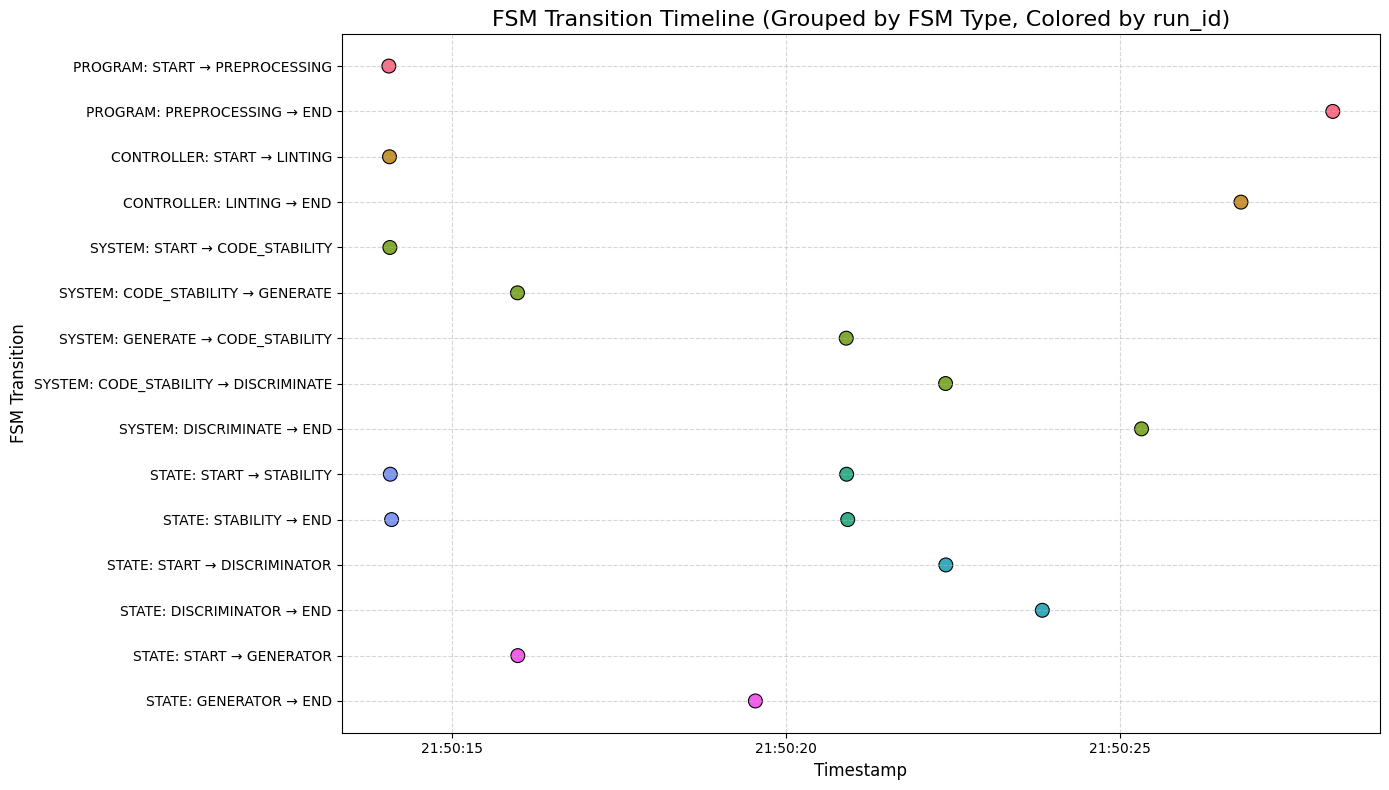

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df_timeline = df.copy()

fsm_order = ["PROGRAM", "CONTROLLER", "SYSTEM", "STATE"]
df_timeline['entity_layer'] = df_timeline['entity_type'].str.split('.').str[-1]
df_timeline['entity_order'] = df_timeline['entity_layer'].apply(lambda x: fsm_order.index(x) if x in fsm_order else 999)

df_timeline = df_timeline.sort_values(by=['entity_order', 'run_id', 'timestamp']).reset_index(drop=True)

df_timeline['label'] = df_timeline.apply(
    lambda row: f"{row['entity_layer']}: {row['from_state'].split('.')[-1]} → {row['to_state'].split('.')[-1]}", axis=1
)

unique_runs = df_timeline['run_id'].unique()
palette = sns.color_palette("husl", len(unique_runs))
run_color_map = dict(zip(unique_runs, palette))
df_timeline['color'] = df_timeline['run_id'].map(run_color_map)

plt.figure(figsize=(14, 8))
sns.scatterplot(
    x='timestamp',
    y='label',
    data=df_timeline,
    hue='run_id',
    palette=run_color_map,
    s=100,
    edgecolor='black',
    legend=False
)

plt.title("FSM Transition Timeline (Grouped by FSM Type, Colored by run_id)", fontsize=16)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("FSM Transition", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



### 📊 FSM Transition Gantt Chart (Grouped by FSM Type)

This cell generates a **Gantt chart** that visually represents **FSM transitions** over time, grouped by type and color-coded by `run_id`.

#### 🧠 What this code does:

* **Prepares the data**:

  * Groups and sorts the FSM transitions by their **layer type** (Program → Controller → System → State) and by **timestamp** to show the correct execution order.
  * Converts timestamps into **Unix seconds** to align with a time scale.
  * Ensures that **duration** is never zero for visibility.
  * Creates **labels** for each transition in the format `EntityLayer: FROM → TO`.
* **Color Mapping**:

  * Each `run_id` is mapped to a distinct color to differentiate parallel runs visually.
* **Plotting**:

  * The Gantt chart is plotted using horizontal bars where each bar represents a **transition**.
  * Bars are color-coded by `run_id`, grouped by **entity type** (Program → Controller → System → State).
* **Axis formatting**:

  * The **y-axis** is inverted to display transitions from top-down in **FSM order**.
  * The **x-axis** represents **Unix time** (seconds) to show when transitions occur.

#### 🔍 What you're observing:

* **FSM transitions**: Each bar represents a transition between states in the FSM, showing **how control flows** between Program, Controller, System, and State.
* **Grouping**: The transitions are grouped and ordered by the **FSM type**, ensuring that you see the hierarchy of execution.
* **Run differentiation**: Different `run_id` colors allow you to visually track distinct runs, helping you analyze different paths or executions of the same FSM.

This **Gantt chart** serves as an excellent tool for **analyzing the flow of state transitions**, spotting execution bottlenecks, or comparing transitions across multiple runs.


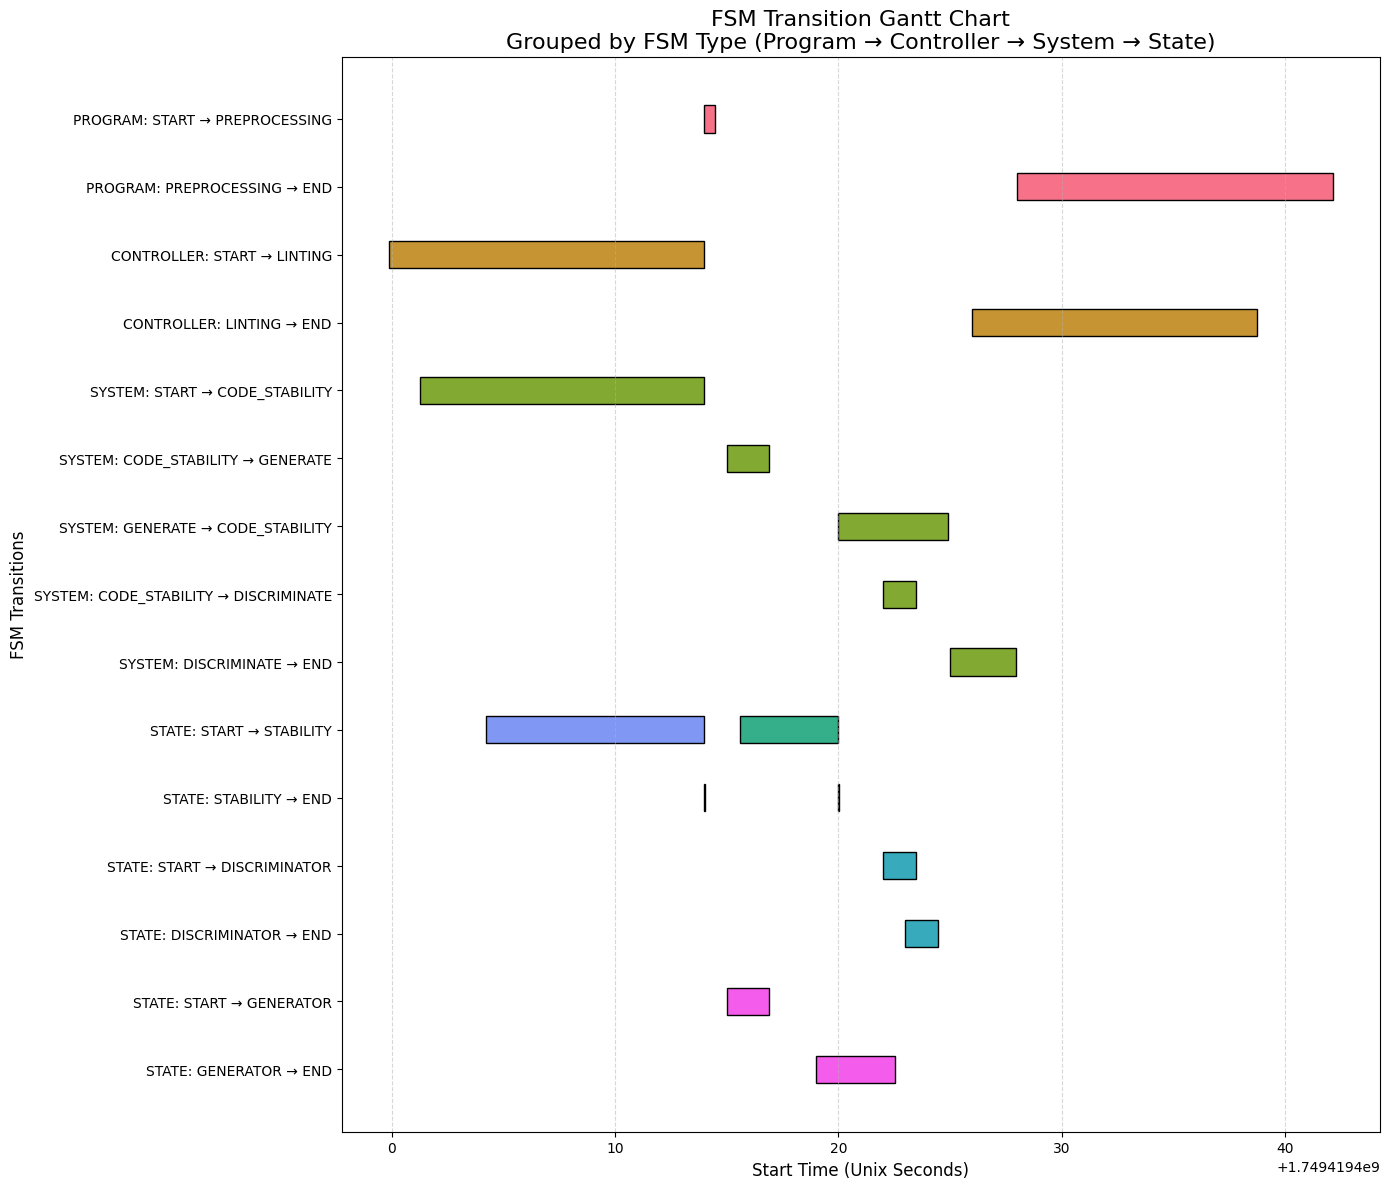

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df_gantt = df.copy()

fsm_order = ["PROGRAM", "CONTROLLER", "SYSTEM", "STATE"]
df_gantt['entity_layer'] = df_gantt['entity_type'].str.split('.').str[-1]
df_gantt['entity_order'] = df_gantt['entity_layer'].apply(lambda x: fsm_order.index(x) if x in fsm_order else 999)

df_gantt = df_gantt.sort_values(by=['entity_order', 'run_id', 'timestamp']).reset_index(drop=True)

df_gantt['start_unix'] = df_gantt['timestamp'].astype('int64') // 10**9

df_gantt['duration'] = df_gantt['timestamp'].diff().dt.total_seconds().fillna(0.5) 

df_gantt['duration'] = df_gantt['duration'].replace(0, 1)

df_gantt['label'] = df_gantt.apply(
    lambda row: f"{row['entity_layer']}: {row['from_state'].split('.')[-1]} → {row['to_state'].split('.')[-1]}", axis=1
)

unique_runs = df_gantt['run_id'].unique()
palette = sns.color_palette("husl", len(unique_runs))
run_color_map = dict(zip(unique_runs, palette))

plt.figure(figsize=(14, 12))
for _, row in df_gantt.iterrows():
    plt.barh(
        y=row['label'],
        width=row['duration'],
        left=row['start_unix'],
        height=0.4,
        color=run_color_map[row['run_id']],
        edgecolor='black'
    )

plt.title("FSM Transition Gantt Chart\nGrouped by FSM Type (Program → Controller → System → State)", fontsize=16)
plt.xlabel("Start Time (Unix Seconds)", fontsize=12)
plt.ylabel("FSM Transitions", fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()



### 📊 Steps per FSM Type

This code generates a **bar chart** showing the **maximum number of steps** taken by each **FSM entity type** (Program, Controller, System, State).

#### 🧠 What this code does:

* **Counts steps**: Uses `cumcount()` to count steps per entity type, ensuring transitions are tracked correctly.

* **Groups by entity type**: Groups the data by `entity_type` and counts the **maximum number of steps** for each FSM type.

* **Label Formatting**: Modifies the x-axis labels to show only the part of the **entity type** after the final period (`.`), so the label is cleaner (e.g., `PROGRAM`, `CONTROLLER` instead of `PROVIDER_TYPE.PROGRAM`).

* **Plotting**:

  * Creates a **bar chart** where the height of each bar represents the number of steps for each FSM type.
  * The **x-axis** shows the FSM types (Program, Controller, System, State), and the **y-axis** shows the **step counts**.

#### 🔍 What you're observing:

* **Bar chart** showing the **step counts** per FSM type.
* The bars reflect the **maximum number of steps** taken by each type during execution, giving insight into how complex or long-running each FSM layer is.
* Helps identify whether certain layers (e.g., **Program** or **Controller**) require more steps for transitions than others.

This chart is a useful tool for **analyzing FSM complexity**, identifying bottlenecks, and understanding which parts of the system involve more transitions or processing steps.

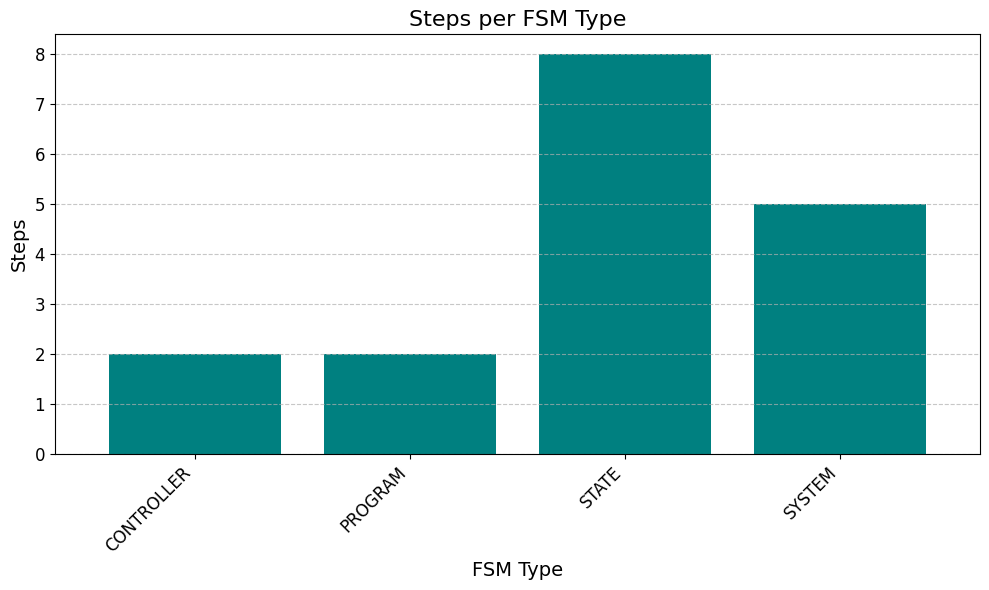

In [6]:
import matplotlib.pyplot as plt

df['step_count'] = df.groupby('entity_type').cumcount() + 1

steps_per_fsm_type = df.groupby('entity_type')['step_count'].max()

steps_per_fsm_type.index = steps_per_fsm_type.index.str.split('.').str[-1]

plt.figure(figsize=(10, 6))
ax = steps_per_fsm_type.plot(kind='bar', color='teal', width=0.8)

plt.title('Steps per FSM Type', fontsize=16)
plt.ylabel('Steps', fontsize=14)
plt.xlabel('FSM Type', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### 📊 Transition Reason Distribution

This code generates a **countplot** to visualize the distribution of **transition reasons** across the FSM state transitions.

#### 🧠 What this code does:

* **Prepares the data**: The `reason_label` column is created by splitting the `reason` field, showing only the part of the reason after the last period (`.`), making the labels more readable (e.g., `SUCCESSFUL` instead of `TRANSITION_REASON_TYPE.SUCCESSFUL`).

* **Creates a countplot**:

  * The `x-axis` shows **transition reasons**, and the `y-axis` shows the **count of occurrences** for each reason.
  * **Color-coded** by reason, where each reason has its own distinct color to aid in visual differentiation.

#### 🔍 What you're observing:

* A **countplot** showing the **distribution of transition reasons** across all recorded FSM transitions.
* The **x-axis** labels represent different types of reasons for state transitions (such as `INITIALIZATION`, `SUCCESSFUL`, `EVALUATING`, etc.).
* The **y-axis** shows how often each reason occurs in the data, providing insight into the frequency of different transition types.

This visualization helps you quickly assess the **most common reasons** for transitions and identify potential patterns or anomalies in the state machine's operation.

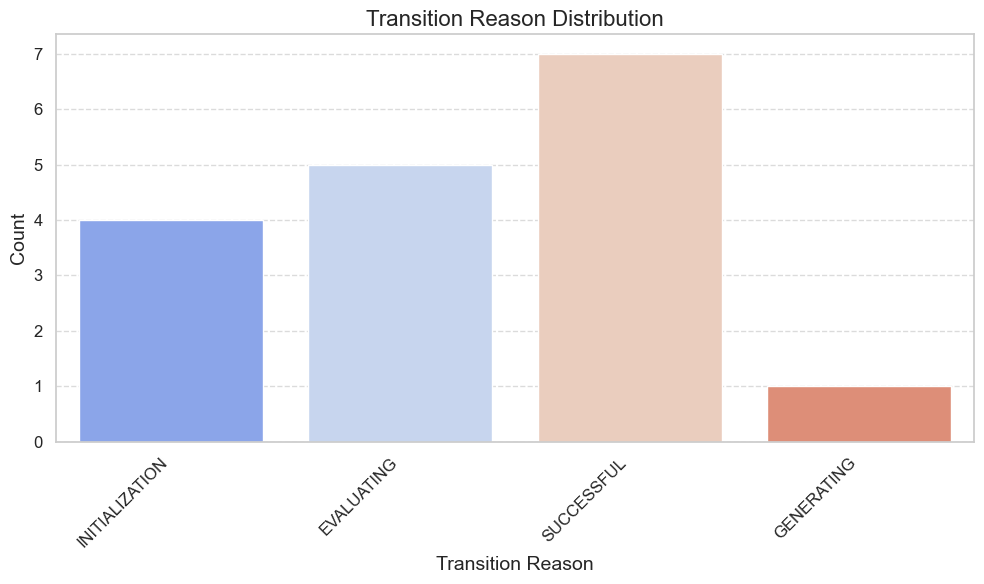

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

df['reason_label'] = df['reason'].apply(lambda x: x.split('.')[-1] if isinstance(x, str) else x)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='reason_label', data=df, hue='reason_label', palette='coolwarm', legend=False)

plt.title("Transition Reason Distribution", fontsize=16)
plt.xlabel('Transition Reason', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)

plt.yticks(fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
